# ***Годограф Цыпкина-Поляка. Робастная устойчивость - квадрат.***

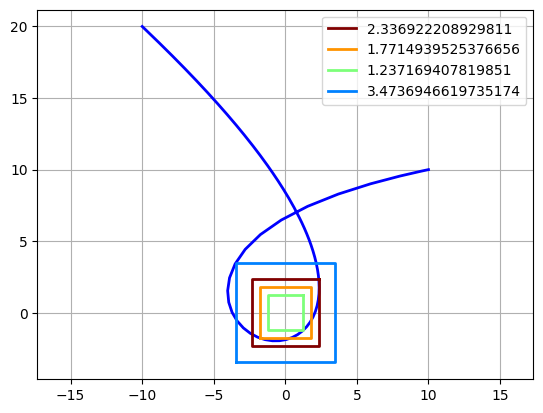

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def robust_stability_square():

    # Коэффициенты полиномов
    ncffs = np.array([433.5, 667.25, 502.72, 251.25, 80.25, 14, 1])
    bcffs = np.array([43.35, 33.36, 25.137, 15.075, 5.6175, 1.4, 0.1])

    polydim = len(ncffs)

    u0cffs = np.zeros(polydim)
    uacffs = np.zeros(polydim)

    for k in range(polydim - 1, -1, -2):
        u0cffs[k] = (-1)**((polydim - 1 - k)//2) * ncffs[k]
        uacffs[k] = bcffs[k]

    v0cffs = np.zeros(polydim)
    vacffs = np.zeros(polydim)

    for k in range(polydim - 2, -1, -2):
        v0cffs[k + 1] = (-1)**((polydim - 2 - k)//2) * ncffs[k]
        vacffs[k + 1] = bcffs[k]

    # Частотная сетка
    count = 5001
    omega_ticks = np.linspace(0, 100, count)
    xy_ticks = np.zeros((2, count))

    for k in range(count):
        omega = omega_ticks[k]
        xy_ticks[0, k] = np.polyval(u0cffs, omega) / np.polyval(uacffs, omega)
        xy_ticks[1, k] = np.polyval(v0cffs, omega) / np.polyval(vacffs, omega)

    # Полиномы wp и wm
    wp = np.convolve(u0cffs, vacffs) - np.convolve(v0cffs, uacffs)
    wm = np.convolve(u0cffs, vacffs) + np.convolve(v0cffs, uacffs)

    rts = np.concatenate((np.roots(wp), np.roots(wm)))
    rts = rts[(rts > 0) & (np.isreal(rts))].real

    deltas = []
    for r in rts:
        delta = np.polyval(u0cffs, r) / np.polyval(uacffs, r)
        deltas.append(delta)

    deltas = np.array(deltas)
    labels = [str(abs(d)) for d in deltas]

    colors = plt.cm.jet(np.linspace(0, 1, 5))[::-1]
    plt.plot(xy_ticks[0, :], xy_ticks[1, :], 'b', linewidth=2.0)

    for k in range(len(deltas)):
        delta = deltas[k]
        vtx_pnts = np.array([
            [ delta, -delta, -delta,  delta,  delta],
            [ delta,  delta, -delta, -delta,  delta]
        ])
        plt.plot(vtx_pnts[0, :], vtx_pnts[1, :],
                 color=colors[k], linewidth=2.0,
                 label=labels[k])

    plt.grid(True)
    plt.axis('equal')
    plt.legend()
    plt.show()


if __name__ == "__main__":
    robust_stability_square()

# **Из чисел, которые представлены на сетке с разными цветами, совпадающими с цветами квадратов, нужно выбрать минимальное, так как это уже δ***

Данный скрипт находит все точки касания годографа и квадратов с длиной стороны δ. Для нахождения радиуса робастной устойчивости δmax следует в конце воспользоваться следующей формулой:    δmax = min{δ*; a0_0/alpha_0; an_0/alpha_n}, где δ* - размер наибольшего квадрата вписанного в годограф.